In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time
import scipy.stats as st
from scipy.stats import randint,uniform
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.tree import export_text
import graphviz
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor

In [2]:
df = pd.read_csv("../data/clean/airbnbnyc_final.csv")
df.head()

,host_is_superhost,neighbourhood_group_cleansed,latitude,longitude,room_type,accommodates,bedrooms,price,maximum_nights,availability_365,number_of_reviews,calculated_host_listings_count,reviews_per_month,total_amenities
0,False,Brooklyn,40.64529,-73.97238,Private room,1.098612,0.693147,5.655992,730,347,2.302585,1.945910,0.076961,761
1,False,Manhattan,40.75356,-73.98559,Entire home/apt,0.693147,0.000000,5.484797,1125,312,3.912023,1.386294,0.231112,553
2,False,Brooklyn,40.66265,-73.99454,Entire home/apt,1.609438,1.098612,5.375278,730,80,1.609438,0.693147,0.029559,816
3,True,Brooklyn,40.70935,-73.95342,Entire home/apt,1.386294,1.098612,4.584967,120,219,5.283204,0.693147,0.693147,384
4,False,Manhattan,40.78778,-73.94759,Private room,0.693147,1.098612,4.158883,120,254,5.537334,0.693147,0.845868,364


# Train test Split

In [3]:

features = df.drop(columns = ["price"])
target = df["price"]
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=0)

# Encoding Categorical Column

In [4]:
ohe = OneHotEncoder(drop="first",sparse_output=False) 
ohe.fit(X_train[['host_is_superhost','neighbourhood_group_cleansed','room_type']]) # The .fit() method determines the unique values of each column
X_train_trans_np = ohe.transform(X_train[['host_is_superhost','neighbourhood_group_cleansed','room_type']])
X_train_trans_df = pd.DataFrame(X_train_trans_np, columns=ohe.get_feature_names_out(), index=X_train.index)
X_test_trans_np = ohe.transform(X_test[['host_is_superhost','neighbourhood_group_cleansed','room_type']])
X_test_trans_df = pd.DataFrame(X_test_trans_np, columns=ohe.get_feature_names_out(), index=X_test.index)

# Saving Encoder

In [5]:
with open("../encoders/one_hot_encoder.pkl", "wb") as file:
    pickle.dump(ohe, file)

# Combining data after encoding

In [6]:
X_train_num=X_train.select_dtypes('number')

X_test_num=X_test.select_dtypes('number')

X_train_full=pd.concat([X_train_trans_df,X_train_num],axis=1)
X_test_full=pd.concat([X_test_trans_df,X_test_num],axis=1)

# Scaling

In [7]:
std_scaler = StandardScaler()
std_scaler.fit(X_train_full)


,copy,True
,with_mean,True
,with_std,True


# Saving scaler

In [8]:
with open("../scalers/standard_scaler.pkl", "wb") as file:
    pickle.dump(std_scaler, file)

In [9]:
X_train_full_np = std_scaler.transform(X_train_full)
X_test_full_np  = std_scaler.transform(X_test_full)

X_train_full_np_df = pd.DataFrame(X_train_full_np, columns=X_train_full.columns, index=X_train_full.index)
X_test_full_np_df  = pd.DataFrame(X_test_full_np, columns=X_test_full.columns, index=X_test_full.index)

# KNN Regressor Before Tuning

In [10]:
#KNN Regressor - modeling
knn = KNeighborsRegressor(n_neighbors=9)
#Training KNN to our normalized data
knn.fit(X_train_full_np_df, y_train)

# Predict on test set
y_pred = knn.predict(X_test_full_np_df)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print metrics
print(f"The R² of the model on the TEST set is: {r2: .2f}")
print(f"Mean Absolute Error (MAE): {mae: .2f}")
print(f"Mean Squared Error (MSE): {mse: .2f}")
print(f"Root Mean Squared Error (RMSE): {rmse: .2f}")

The R² of the model on the TEST set is:  0.74
Mean Absolute Error (MAE):  0.32
Mean Squared Error (MSE):  0.21
Root Mean Squared Error (RMSE):  0.46


# Saving model

In [11]:
with open("../models/knn.pkl", "wb") as file:
    pickle.dump(knn, file)

# Hyperparameter Tuning for KNN Regressor

# Grid Search

In [12]:


# Hyperparameter grid
parameter_grid = {
    "n_neighbors": [3,5,10,20],
    "weights": ['uniform', 'distance'],
    "leaf_size": [20,30,40],
    "p":[1,2],
    "metric":['minkowski','manhattan','euclidean']
}

# Model
kr = KNeighborsRegressor()

# GridSearchCV setup
confidence_level = 0.95
folds = 5
gs = GridSearchCV(kr, param_grid=parameter_grid, cv=folds, verbose=1, scoring='r2', n_jobs=-1)

# Fit model
start_time = time.time()
gs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Results
print(f"\nTime taken: {end_time - start_time:.2f} seconds")
print("Best hyperparameters:", gs.best_params_)
print(f"Cross-validated R2 score: {gs.best_score_:.4f}")

# Confidence interval
results_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0]["mean_test_score"]
std_score = results_df.iloc[0]["std_test_score"]
sem = std_score / np.sqrt(folds)
tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
lower_bound = mean_score - tc * sem
upper_bound = mean_score + tc * sem

print(f"95% Confidence Interval for R2: ({lower_bound:.4f}, {mean_score:.4f}, {upper_bound:.4f})")

# Final model evaluation
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_full_np_df)

print("\n Test Evaluation:")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred) * 100:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Time taken: 53.56 seconds
Best hyperparameters: {'leaf_size': 20, 'metric': 'minkowski', 'n_neighbors': 10, 'p': 1, 'weights': 'distance'}
Cross-validated R2 score: 0.7603
95% Confidence Interval for R2: (0.7464, 0.7603, 0.7742)

 Test Evaluation:
MAE : 0.2878
MSE : 0.1783
RMSE: 0.4222
R2  : 0.7822
MAPE  : 5.6966


# Random Search

In [13]:
# Define parameters
parameter_distributions = {
    "n_neighbors":randint(1,50),
    "weights": ['uniform', 'distance'],
    "p":[1,2],
    "leaf_size":randint(10,100),
    "algorithm":['auto','ball_tree','kd_tree','brute']
    
}

# Model instance
kr1 =  KNeighborsRegressor()

# Setup RandomizedSearchCV
confidence_level = 0.95
folds = 5
n_iter = 30

rs = RandomizedSearchCV(
    kr,
    param_distributions=parameter_distributions,
    n_iter=n_iter,
    cv=folds,
    verbose=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# Fit the model
start_time = time.time()
rs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Display results
print("\n")
print(f"Time taken to find the best combination of hyperparameters: {end_time - start_time:.4f} seconds\n")
print("Best hyperparameters:", rs.best_params_)
print(f"Best cross-validated R2: {rs.best_score_:.4f}")

# Confidence interval calculation
results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)
rs_mean_score = results_rs_df.iloc[0]["mean_test_score"]
rs_std_score = results_rs_df.iloc[0]["std_test_score"]
rs_sem = rs_std_score / np.sqrt(folds)

rs_tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
rs_lower_bound = rs_mean_score - rs_tc * rs_sem
rs_upper_bound = rs_mean_score + rs_tc * rs_sem

print(f"R2 confidence interval for the best combination: ({rs_lower_bound:.4f}, {rs_mean_score:.4f}, {rs_upper_bound:.4f})")

# Evaluate on test set
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test_full_np_df)

print("\n Test Set Evaluation:")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Test R2  : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred_test) * 100:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Time taken to find the best combination of hyperparameters: 30.9949 seconds

Best hyperparameters: {'algorithm': 'kd_tree', 'leaf_size': 96, 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}
Best cross-validated R2: 0.7599
R2 confidence interval for the best combination: (0.7464, 0.7599, 0.7734)

 Test Set Evaluation:
Test MAE : 0.2883
Test MSE : 0.1787
Test RMSE: 0.4227
Test R2  : 0.7817
MAPE  : 5.7046


# Bayesian Search

In [14]:

# Objective function for Bayesian search
def objective(trial, confidence_level, folds):
    # Suggest hyperparameters
    n_neighbors = trial.suggest_int("n_neighbors", 1, 50)
    weights = trial.suggest_categorical("weights",['uniform','distance'])
    p = trial.suggest_int("p", 1, 2)
    leaf_size = trial.suggest_int("leaf_size", 10, 100)
    algorithm = trial.suggest_categorical("agorithm", ['auto','ball_tree','kd_tree','brute'])

    # Initialize model
    kr2 = KNeighborsRegressor(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p,
        leaf_size=leaf_size,
        algorithm=algorithm
    )

    # Cross-validation
    scores = cross_val_score(kr2, X_train_full_np_df, y_train, cv=folds, scoring='r2')
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Confidence interval
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval in trial
    trial.set_user_attr("CV_score_summary", [
        round(lower_bound, 4),
        round(mean_score, 4),
        round(upper_bound, 4)
    ])

    return mean_score
confidence_level = 0.95
folds = 5

start_time = time.time()
study = optuna.create_study(direction="maximize")  # Maximize R²
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=45)
end_time = time.time()

# Print results
print("\n")
print(f"Time taken: {end_time - start_time: .4f} seconds")
print("\nBest hyperparameters found:", study.best_params)
print(f" Best R² found: {study.best_value: .4f}")

# Extract best trial confidence interval
results = sorted([
    (
        index,
        trial.user_attrs['CV_score_summary'][0],
        trial.user_attrs['CV_score_summary'][1],
        trial.user_attrs['CV_score_summary'][2]
    )
    for index, trial in enumerate(study.trials)
], key=lambda x: x[2], reverse=True)

print(f" R² confidence interval of best trial: {results[0][1:]}")

[I 2025-08-11 08:51:51,341] A new study created in memory with name: no-name-74fd2f7c-17f6-4b08-a10b-741a4a56b5d8
[I 2025-08-11 08:51:52,272] Trial 0 finished with value: 0.7565607632256247 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 1, 'leaf_size': 99, 'agorithm': 'brute'}. Best is trial 0 with value: 0.7565607632256247.
[I 2025-08-11 08:51:56,647] Trial 1 finished with value: 0.7399403559869656 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'p': 2, 'leaf_size': 54, 'agorithm': 'ball_tree'}. Best is trial 0 with value: 0.7565607632256247.
[I 2025-08-11 08:52:05,512] Trial 2 finished with value: 0.7552557948803981 and parameters: {'n_neighbors': 19, 'weights': 'distance', 'p': 1, 'leaf_size': 23, 'agorithm': 'kd_tree'}. Best is trial 0 with value: 0.7565607632256247.
[I 2025-08-11 08:52:06,388] Trial 3 finished with value: 0.7144988300782553 and parameters: {'n_neighbors': 2, 'weights': 'distance', 'p': 1, 'leaf_size': 78, 'agorithm': 'brute'}. Best is t



Time taken:  105.7584 seconds

Best hyperparameters found: {'n_neighbors': 9, 'weights': 'distance', 'p': 1, 'leaf_size': 53, 'agorithm': 'ball_tree'}
 Best R² found:  0.7612
 R² confidence interval of best trial: (np.float64(0.7452), np.float64(0.7612), np.float64(0.7772))


# KNN Regressor After Tuning

In [15]:
knn_tuned = KNeighborsRegressor(n_neighbors=11,algorithm='kd_tree',leaf_size=96,p=1,weights='distance',metric='minkowski')
knn_tuned.fit(X_train_full_np_df, y_train)

,n_neighbors,11
,weights,'distance'
,algorithm,'kd_tree'
,leaf_size,96
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Saving model

In [16]:
with open("../models/knn_tuned.pkl", "wb") as file:
    pickle.dump(knn_tuned, file)

In [17]:

# Predict on test set
y_pred = knn_tuned.predict(X_test_full_np_df)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
# Print metrics
print(f"The R² of the model on the TEST set is: {r2: .2f}")
print(f"Mean Absolute Error (MAE): {mae: .2f}")
print(f"Mean Squared Error (MSE): {mse: .2f}")
print(f"Root Mean Squared Error (RMSE): {rmse: .2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape: .2f}")

The R² of the model on the TEST set is:  0.78
Mean Absolute Error (MAE):  0.29
Mean Squared Error (MSE):  0.18
Root Mean Squared Error (RMSE):  0.42
Mean Absolute Percentage Error (MAPE):  5.70


In [18]:
# Best features to select
model = LinearRegression()
rfe = RFE(estimator=LinearRegression(), n_features_to_select=10)
rfe.fit(X_train_full_np_df, y_train)
selected_columns = X_train_full_np_df.columns[rfe.support_]
print("Selected features:", selected_columns)

Selected features: Index(['neighbourhood_group_cleansed_Brooklyn',
       'neighbourhood_group_cleansed_Manhattan',
       'neighbourhood_group_cleansed_Staten Island', 'room_type_Hotel room',
       'room_type_Private room', 'latitude', 'longitude', 'accommodates',
       'number_of_reviews', 'total_amenities'],
      dtype='object')


# Linear Regression

In [19]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_full_np_df, y_train) # Determines the b0 and b1's values
y_pred_test = lin_reg.predict(X_test_full_np_df)
mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100
#lin_reg.score(X_test_norm, y_test)
print(f"MAE {mean_absolute_error(y_test,y_pred_test): .2f}") # mean(abs(error)) = mean(abs(y_test - y_pred_test))
print(f"MSE {mean_squared_error(y_test,y_pred_test): .2f}") # mean(error**2) = mean((y_test - y_pred_test)**2)
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test): .2f}") # sqrt( mean( (y_test - y_pred_test)^2 ) ) # b0, b1, b2...
print(f"R2 score, {lin_reg.score(X_test_full_np_df, y_test): .2f}") # r2_score
print(f"Mean Absolute Percentage Error (MAPE): {mape: .2f}")

MAE  0.43
MSE  0.33
RMSE,  0.57
R2 score,  0.60
Mean Absolute Percentage Error (MAPE):  8.49


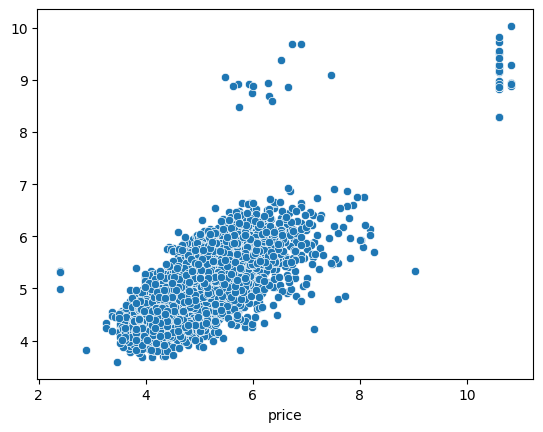

In [20]:
sns.scatterplot(x=y_test, y=y_pred_test); # y_pred_test = y_test;  y_pred_test = 0 + y_test; y_pred_test = 0 + 1 * y_test

# Decision Tree Regressor Before Tuning

In [21]:
#initialize decision tree instance
dtree = DecisionTreeRegressor(max_depth=4)
#train a Decision Tree
dtree.fit(X_train_full_np_df, y_train)
y_pred_test_dt = dtree.predict(X_test_full_np_df)
print(f"MAE, {mean_absolute_error(y_test,y_pred_test_dt): .2f}")
print(f"MSE, {mean_squared_error(y_test,y_pred_test_dt): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test_dt): .2f}")
print(f"R2 score, {dtree.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test, y_pred_test_dt) * 100: .2f}")

MAE,  0.41
MSE,  0.32
RMSE,  0.56
R2 score,  0.61
MAPE,  8.18


# Saving model

In [22]:
with open("../models/dtree.pkl", "wb") as file:
    pickle.dump(dtree, file)

# Hyperparameter Tuning for Decision Tree Regressor

# Grid Search

In [24]:
# Hyperparameter grid
parameter_grid={
    "max_depth": [None,5,10,20],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,5],
    "max_features":[None,0.5,'sqrt','log2'],
    "criterion":['squared_error','absolute_error']
}

# Model
dt=DecisionTreeRegressor(random_state=42)

# GridSearchCV setup
confidence_level = 0.95
folds = 5
gs = GridSearchCV(dt, param_grid=parameter_grid, cv=folds, verbose=1, scoring='r2', n_jobs=-1)

# Fit model
start_time = time.time()
gs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Results
print(f"\nTime taken: {end_time - start_time:.2f} seconds")
print("Best hyperparameters:", gs.best_params_)
print(f"Cross-validated R2 score: {gs.best_score_:.4f}")

# Confidence interval
results_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0]["mean_test_score"]
std_score = results_df.iloc[0]["std_test_score"]
sem = std_score / np.sqrt(folds)
tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
lower_bound = mean_score - tc * sem
upper_bound = mean_score + tc * sem

print(f"95% Confidence Interval for R2: ({lower_bound:.4f}, {mean_score:.4f}, {upper_bound:.4f})")

# Final model evaluation
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_full_np_df)

print("\n Test Evaluation:")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred) * 100:.4f}")

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Time taken: 454.06 seconds
Best hyperparameters: {'criterion': 'squared_error', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Cross-validated R2 score: 0.7214
95% Confidence Interval for R2: (0.7050, 0.7214, 0.7379)

 Test Evaluation:
MAE : 0.3234
MSE : 0.2163
RMSE: 0.4651
R2  : 0.7358
MAPE  : 6.4019


# Random Search

In [25]:
# Define parameters
parameter_distributions = {
    "max_depth": [None,5,10,20,30],
    "min_samples_split": randint(2,20),
    "min_samples_leaf":randint(1,20) ,
    "max_features":[None,0.5,'sqrt','log2'],
    "criterion":['squared_error','absolute_error'],
    "ccp_alpha":uniform(0.0,0.05)
}

# Model instance
dt1 =  DecisionTreeRegressor()

# Setup RandomizedSearchCV
confidence_level = 0.95
folds = 5
n_iter = 50

rs = RandomizedSearchCV(
    dt1,
    param_distributions=parameter_distributions,
    n_iter=n_iter,
    cv=folds,
    verbose=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# Fit the model
start_time = time.time()
rs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Display results
print("\n")
print(f"Time taken to find the best combination of hyperparameters: {end_time - start_time:.4f} seconds\n")
print("Best hyperparameters:", rs.best_params_)
print(f"Best cross-validated R2: {rs.best_score_:.4f}")

# Confidence interval calculation
results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)
rs_mean_score = results_rs_df.iloc[0]["mean_test_score"]
rs_std_score = results_rs_df.iloc[0]["std_test_score"]
rs_sem = rs_std_score / np.sqrt(folds)

rs_tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
rs_lower_bound = rs_mean_score - rs_tc * rs_sem
rs_upper_bound = rs_mean_score + rs_tc * rs_sem

print(f"R2 confidence interval for the best combination: ({rs_lower_bound:.4f}, {rs_mean_score:.4f}, {rs_upper_bound:.4f})")

# Evaluate on test set
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test_full_np_df)

print("\n Test Set Evaluation:")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Test R2  : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred_test) * 100:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Time taken to find the best combination of hyperparameters: 57.2532 seconds

Best hyperparameters: {'ccp_alpha': np.float64(0.004424625102595975), 'criterion': 'squared_error', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 17}
Best cross-validated R2: 0.6391
R2 confidence interval for the best combination: (0.6220, 0.6391, 0.6563)

 Test Set Evaluation:
Test MAE : 0.3908
Test MSE : 0.2857
Test RMSE: 0.5345
Test R2  : 0.6510
MAPE  : 7.7683


# Bayesian Search

In [26]:

# Objective function for Bayesian search
def objective(trial, confidence_level, folds):
    # Suggest hyperparameters
    max_depth = trial.suggest_int("max_depth", 1, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2", 0.5, 0.8, 1.0])
    criterion = trial.suggest_categorical("criterion", ["squared_error", "absolute_error"])
    ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 0.05)

    # Initialize model
    dt2 = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion=criterion,
        ccp_alpha=ccp_alpha,
        random_state=42
    )

    # Cross-validation
    scores = cross_val_score(dt2, X_train_full_np_df, y_train, cv=folds, scoring='r2')
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Confidence interval
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval in trial
    trial.set_user_attr("CV_score_summary", [
        round(lower_bound, 4),
        round(mean_score, 4),
        round(upper_bound, 4)
    ])

    return mean_score
confidence_level = 0.95
folds = 5

start_time = time.time()
study = optuna.create_study(direction="maximize")  # Maximize R²
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=45)
end_time = time.time()

# Print results
print("\n")
print(f"Time taken: {end_time - start_time: .4f} seconds")
print("\nBest hyperparameters found:", study.best_params)
print(f" Best R² found: {study.best_value: .4f}")

# Extract best trial confidence interval
results = sorted([
    (
        index,
        trial.user_attrs['CV_score_summary'][0],
        trial.user_attrs['CV_score_summary'][1],
        trial.user_attrs['CV_score_summary'][2]
    )
    for index, trial in enumerate(study.trials)
], key=lambda x: x[2], reverse=True)

print(f" R² confidence interval of best trial: {results[0][1:]}")

[I 2025-08-11 09:10:44,148] A new study created in memory with name: no-name-dab46042-d5cd-4f8e-bef5-cf12995b7adf
[I 2025-08-11 09:10:44,385] Trial 0 finished with value: 0.4826495307847849 and parameters: {'max_depth': 8, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': 0.5, 'criterion': 'squared_error', 'ccp_alpha': 0.024272239925287376}. Best is trial 0 with value: 0.4826495307847849.
[I 2025-08-11 09:11:17,305] Trial 1 finished with value: 0.4327163543027697 and parameters: {'max_depth': 40, 'min_samples_split': 17, 'min_samples_leaf': 13, 'max_features': 0.8, 'criterion': 'absolute_error', 'ccp_alpha': 0.02547354140297166}. Best is trial 0 with value: 0.4826495307847849.
[I 2025-08-11 09:11:17,782] Trial 2 finished with value: 0.5112922960947152 and parameters: {'max_depth': 41, 'min_samples_split': 11, 'min_samples_leaf': 11, 'max_features': None, 'criterion': 'squared_error', 'ccp_alpha': 0.029438931964924003}. Best is trial 2 with value: 0.5112922960947152.
[I 20



Time taken:  1129.5437 seconds

Best hyperparameters found: {'max_depth': 44, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 1.0, 'criterion': 'absolute_error', 'ccp_alpha': 9.63143298600251e-05}
 Best R² found:  0.7139
 R² confidence interval of best trial: (np.float64(0.6895), np.float64(0.7139), np.float64(0.7382))


# Decision Tree Regressor After Tuning

In [27]:
#initialize decision tree instance
dtree_tuned = DecisionTreeRegressor(max_depth=10 ,min_samples_split=10 ,min_samples_leaf=2,max_features=None,criterion='squared_error')
#train a Decision Tree
dtree_tuned.fit(X_train_full_np_df, y_train)
y_pred_test_dt = dtree_tuned.predict(X_test_full_np_df)
print(f"MAE, {mean_absolute_error(y_test,y_pred_test_dt): .2f}")
print(f"MSE, {mean_squared_error(y_test,y_pred_test_dt): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test_dt): .2f}")
print(f"R2 score, {dtree_tuned.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test, y_pred_test_dt) * 100: .2f}")

MAE,  0.32
MSE,  0.22
RMSE,  0.47
R2 score,  0.73
MAPE,  6.41


# Saving Model

In [28]:
with open("../models/dtree_tuned.pkl", "wb") as file:
    pickle.dump(dtree_tuned, file)

Important features

In [29]:
tree_importance = {feature : importance for feature, importance in zip(X_train_full_np_df.columns, dtree_tuned.feature_importances_)}
tree_importance

{'host_is_superhost_No info available': np.float64(0.0),
 'host_is_superhost_True': np.float64(0.00015371911691014362),
 'neighbourhood_group_cleansed_Brooklyn': np.float64(0.0),
 'neighbourhood_group_cleansed_Manhattan': np.float64(0.002257660193353835),
 'neighbourhood_group_cleansed_Queens': np.float64(0.00018673404369773223),
 'neighbourhood_group_cleansed_Staten Island': np.float64(5.6699624662475616e-05),
 'room_type_Hotel room': np.float64(0.19744936311674313),
 'room_type_Private room': np.float64(0.27592009941081513),
 'room_type_Shared room': np.float64(0.0048187215629753605),
 'latitude': np.float64(0.06236046132992318),
 'longitude': np.float64(0.11869475991848459),
 'accommodates': np.float64(0.1280692993860358),
 'bedrooms': np.float64(0.01835779102524218),
 'maximum_nights': np.float64(0.01044422176287357),
 'availability_365': np.float64(0.03521742382918052),
 'number_of_reviews': np.float64(0.004211873672936931),
 'calculated_host_listings_count': np.float64(0.09586435

Tree Visualization

In [30]:
tree_viz = export_text(dtree_tuned, feature_names=list(X_train_full_np_df.columns))
#print(tree_viz)

Graph vizualization

In [31]:
#dot_data = export_graphviz(dtree_tuned, out_file="tree.dot", filled=True, rounded=True, feature_names=X_train_full_np_df.columns)
#with open("tree.dot") as f:
#    dot_graph = f.read()
#graphviz.Source(dot_graph)

# Random Forest Regressor Before Tuning

In [32]:
#initialize a random Forest
rforest = RandomForestRegressor(n_estimators=200,
                             max_depth=30)
#Training the model
rforest.fit(X_train_full_np_df, y_train)
#Evaluate the model
y_pred_test_rf = rforest.predict(X_test_full_np_df)

print(f"MAE, {mean_absolute_error(y_test, y_pred_test_rf): .2f}")
print(f"MSE, {mean_squared_error(y_test, y_pred_test_rf): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test, y_pred_test_rf): .2f}")
print(f"R2 score, {rforest.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test, y_pred_test_rf) * 100: .2f}")

MAE,  0.26
MSE,  0.16
RMSE,  0.40
R2 score,  0.81
MAPE,  5.23


# Saving Model

In [33]:
with open("../models/rforest.pkl", "wb") as file:
    pickle.dump(rforest, file)

# Hyperparameter Tuning for Random Forest Regressor

# Grid Search

In [37]:
# Hyperparameter grid
parameter_grid={
    
    'n_estimators': [100, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['log2', 'sqrt']
}

# Model
rf=RandomForestRegressor(random_state=42)

# GridSearchCV setup
confidence_level = 0.95
folds = 5
gs = GridSearchCV(rf, param_grid=parameter_grid, cv=folds, verbose=1, scoring='r2', n_jobs=-1)

# Fit model
start_time = time.time()
gs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Results
print(f"\nTime taken: {end_time - start_time:.2f} seconds")
print("Best hyperparameters:", gs.best_params_)
print(f"Cross-validated R2 score: {gs.best_score_:.4f}")

# Confidence interval
results_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0]["mean_test_score"]
std_score = results_df.iloc[0]["std_test_score"]
sem = std_score / np.sqrt(folds)
tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
lower_bound = mean_score - tc * sem
upper_bound = mean_score + tc * sem

print(f"95% Confidence Interval for R2: ({lower_bound:.4f}, {mean_score:.4f}, {upper_bound:.4f})")

# Final model evaluation
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_full_np_df)

print("\n Test Evaluation:")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred) * 100:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Time taken: 137.08 seconds
Best hyperparameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Cross-validated R2 score: 0.8032
95% Confidence Interval for R2: (0.7955, 0.8032, 0.8109)

 Test Evaluation:
MAE : 0.2611
MSE : 0.1498
RMSE: 0.3871
R2  : 0.8170
MAPE  : 5.1863


# Random Search

In [43]:
# Define parameters
parameter_distributions = {

    'n_estimators': randint(100, 300),
    'max_depth': randint(10, 40),
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# Model instance
rf1 =  RandomForestRegressor()

# Setup RandomizedSearchCV
confidence_level = 0.95
folds = 5
n_iter = 50

rs = RandomizedSearchCV(
    rf1,
    param_distributions=parameter_distributions,
    n_iter=n_iter,
    cv=folds,
    verbose=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# Fit the model
start_time = time.time()
rs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Display results
print("\n")
print(f"Time taken to find the best combination of hyperparameters: {end_time - start_time:.4f} seconds\n")
print("Best hyperparameters:", rs.best_params_)
print(f"Best cross-validated R2: {rs.best_score_:.4f}")

# Confidence interval calculation
results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)
rs_mean_score = results_rs_df.iloc[0]["mean_test_score"]
rs_std_score = results_rs_df.iloc[0]["std_test_score"]
rs_sem = rs_std_score / np.sqrt(folds)

rs_tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
rs_lower_bound = rs_mean_score - rs_tc * rs_sem
rs_upper_bound = rs_mean_score + rs_tc * rs_sem

print(f"R2 confidence interval for the best combination: ({rs_lower_bound:.4f}, {rs_mean_score:.4f}, {rs_upper_bound:.4f})")

# Evaluate on test set
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test_full_np_df)

print("\n Test Set Evaluation:")
print(f"Test MAE : {mean_absolute_error(y_test,y_pred_test):.4f}")
print(f"Test MSE : {mean_squared_error(y_test,y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")
print(f"Test R2  : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test,y_pred_test) * 100:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Time taken to find the best combination of hyperparameters: 146.0839 seconds

Best hyperparameters: {'max_depth': 26, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 269}
Best cross-validated R2: 0.8030
R2 confidence interval for the best combination: (0.7954, 0.8030, 0.8107)

 Test Set Evaluation:
Test MAE : 0.2620
Test MSE : 0.1503
Test RMSE: 0.3877
Test R2  : 0.8163
MAPE  : 5.2001


# Bayesian Search

In [44]:

# Objective function for Bayesian search
def objective(trial, confidence_level, folds):
    # Suggest hyperparameters
    params={'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42
    }

    # Initialize model
    rf2 = RandomForestRegressor(**params)
    

    # Cross-validation
    scores = cross_val_score(rf2, X_train_full_np_df, y_train, cv=folds, scoring='r2')
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Confidence interval
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval in trial
    trial.set_user_attr("CV_score_summary", [
        round(lower_bound, 4),
        round(mean_score, 4),
        round(upper_bound, 4)
    ])

    return mean_score
confidence_level = 0.95
folds = 5

start_time = time.time()
study = optuna.create_study(direction="maximize")  # Maximize R²
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=45)
end_time = time.time()

# Print results
print("\n")
print(f"Time taken: {end_time - start_time: .4f} seconds")
print("\nBest hyperparameters found:", study.best_params)
print(f" Best R² found: {study.best_value: .4f}")

# Extract best trial confidence interval
results = sorted([
    (
        index,
        trial.user_attrs['CV_score_summary'][0],
        trial.user_attrs['CV_score_summary'][1],
        trial.user_attrs['CV_score_summary'][2]
    )
    for index, trial in enumerate(study.trials)
], key=lambda x: x[2], reverse=True)

print(f" R² confidence interval of best trial: {results[0][1:]}")

[I 2025-08-11 10:14:52,539] A new study created in memory with name: no-name-cdf23571-98ae-4416-9f15-4a3038188481
[I 2025-08-11 10:15:22,381] Trial 0 finished with value: 0.7981577165742139 and parameters: {'n_estimators': 297, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.7981577165742139.
[I 2025-08-11 10:15:28,969] Trial 1 finished with value: 0.649416670450446 and parameters: {'n_estimators': 149, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.7981577165742139.
[I 2025-08-11 10:15:41,760] Trial 2 finished with value: 0.783526810794584 and parameters: {'n_estimators': 158, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.7981577165742139.
[I 2025-08-11 10:16:03,429] Trial 3 finished with value: 0.7864117359134497 an



Time taken:  1430.0408 seconds

Best hyperparameters found: {'n_estimators': 237, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False}
 Best R² found:  0.8065
 R² confidence interval of best trial: (np.float64(0.7972), np.float64(0.8065), np.float64(0.8157))


# Random Forest Regressor After Tuning

In [45]:
#initialize a random Forest
rforest_tuned = RandomForestRegressor(max_depth=39,max_features='log2',min_samples_leaf=1,min_samples_split=2,n_estimators=271,bootstrap=False,random_state=42)
#Training the model
rforest_tuned.fit(X_train_full_np_df, y_train)
#Evaluate the model
y_pred_test_rf = rforest_tuned.predict(X_test_full_np_df)

print(f"MAE, {mean_absolute_error(y_test,y_pred_test_rf): .2f}")
print(f"MSE, {mean_squared_error(y_test,y_pred_test_rf): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test_rf): .2f}")
print(f"R2 score, {rforest_tuned.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test,y_pred_test_rf) * 100: .2f}")

MAE,  0.25
MSE,  0.15
RMSE,  0.39
R2 score,  0.82
MAPE,  5.05


# Saving Model

In [46]:
with open("../models/rforest_tuned.pkl", "wb") as file:
    pickle.dump(rforest_tuned, file)

# Ada Boost Regressor Before Tuning

In [47]:
#Initialize an AdaBoost model
ada = AdaBoostRegressor(DecisionTreeRegressor(max_depth=20),
                            n_estimators=100)
#Training the model
ada.fit(X_train_full_np_df, y_train)
y_pred_test_ada = ada.predict(X_test_full_np_df)
#Evaluate the model
print(f"MAE, {mean_absolute_error(y_test,y_pred_test_ada): .2f}")
print(f"MSE, {mean_squared_error(y_test,y_pred_test_ada): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test_ada): .2f}")
print(f"R2 score, {ada.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test,y_pred_test_ada) * 100: .2f}")

MAE,  0.29
MSE,  0.17
RMSE,  0.41
R2 score,  0.79
MAPE,  5.78


# Saving Model

In [48]:
with open("../models/ada.pkl", "wb") as file:
    pickle.dump(ada, file)

# Hyperparameter Tuning for Ada Boost Regressor

# Grid Search

In [49]:
# Hyperparameter grid
parameter_grid={
    
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'loss': ['linear', 'square', 'exponential'],
    'estimator__max_depth': [10, 15, 20]
}

base_estimator=DecisionTreeRegressor()
ab=AdaBoostRegressor


# GridSearchCV setup
confidence_level = 0.95
folds = 5
gs = GridSearchCV(estimator=ab(random_state=42,estimator=base_estimator), param_grid=parameter_grid, cv=folds, verbose=1, scoring='r2', n_jobs=-1)

# Fit model
start_time = time.time()
gs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Results
print(f"\nTime taken: {end_time - start_time:.2f} seconds")
print("Best hyperparameters:", gs.best_params_)
print(f"Cross-validated R2 score: {gs.best_score_:.4f}")

# Confidence interval
results_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0]["mean_test_score"]
std_score = results_df.iloc[0]["std_test_score"]
sem = std_score / np.sqrt(folds)
tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
lower_bound = mean_score - tc * sem
upper_bound = mean_score + tc * sem

print(f"95% Confidence Interval for R2: ({lower_bound:.4f}, {mean_score:.4f}, {upper_bound:.4f})")

# Final model evaluation
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_full_np_df)

print("\n Test Evaluation:")
print(f"MAE : {mean_absolute_error(y_test,y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test,y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test,y_pred)):.4f}")
print(f"R2  : {r2_score(y_test,y_pred):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test,y_pred) * 100:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Time taken: 444.13 seconds
Best hyperparameters: {'estimator__max_depth': 20, 'learning_rate': 0.1, 'loss': 'square', 'n_estimators': 200}
Cross-validated R2 score: 0.7994
95% Confidence Interval for R2: (0.7908, 0.7994, 0.8080)

 Test Evaluation:
MAE : 0.2539
MSE : 0.1598
RMSE: 0.3998
R2  : 0.8048
MAPE  : 5.0016


# Random Search

In [50]:
# Define parameters
parameter_distributions = {

    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 1.0),
    'loss': ['linear', 'square', 'exponential'],
    'estimator__max_depth': randint(10, 20)
}
#base estimator
base_estimator=DecisionTreeRegressor()
#model
ab1 =  AdaBoostRegressor(estimator=base_estimator,random_state=42)

# Setup RandomizedSearchCV
confidence_level = 0.95
folds = 5
n_iter = 50

rs = RandomizedSearchCV(
    estimator=ab1,
    param_distributions=parameter_distributions,
    n_iter=n_iter,
    cv=folds,
    verbose=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# Fit the model
start_time = time.time()
rs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Display results
print("\n")
print(f"Time taken to find the best combination of hyperparameters: {end_time - start_time:.4f} seconds\n")
print("Best hyperparameters:", rs.best_params_)
print(f"Best cross-validated R2: {rs.best_score_:.4f}")

# Confidence interval calculation
results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)
rs_mean_score = results_rs_df.iloc[0]["mean_test_score"]
rs_std_score = results_rs_df.iloc[0]["std_test_score"]
rs_sem = rs_std_score / np.sqrt(folds)

rs_tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
rs_lower_bound = rs_mean_score - rs_tc * rs_sem
rs_upper_bound = rs_mean_score + rs_tc * rs_sem

print(f"R2 confidence interval for the best combination: ({rs_lower_bound:.4f}, {rs_mean_score:.4f}, {rs_upper_bound:.4f})")

# Evaluate on test set
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test_full_np_df)

print("\n Test Set Evaluation:")
print(f"Test MAE : {mean_absolute_error(y_test,y_pred_test):.4f}")
print(f"Test MSE : {mean_squared_error(y_test,y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test,y_pred_test)):.4f}")
print(f"Test R2  : {r2_score(y_test,y_pred_test):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test,y_pred_test) * 100:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Time taken to find the best combination of hyperparameters: 262.9632 seconds

Best hyperparameters: {'estimator__max_depth': 19, 'learning_rate': np.float64(0.13208795470067336), 'loss': 'linear', 'n_estimators': 280}
Best cross-validated R2: 0.7996
R2 confidence interval for the best combination: (0.7933, 0.7996, 0.8059)

 Test Set Evaluation:
Test MAE : 0.2575
Test MSE : 0.1568
Test RMSE: 0.3960
Test R2  : 0.8084
MAPE  : 5.0958


# Bayesian Search

In [51]:

# Objective function for Bayesian search
def objective(trial, confidence_level, folds):
    # Suggest hyperparameters
    
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)
    loss = trial.suggest_categorical("loss", ["linear", "square", "exponential"])
    max_depth = trial.suggest_int("max_depth", 15, 20)
    
    base_estimator=DecisionTreeRegressor(max_depth=max_depth)
    # Initialize model
    ab2 = AdaBoostRegressor(
        estimator=base_estimator,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        loss=loss,
        random_state=42
    )
    

    # Cross-validation
    scores = cross_val_score(ab2, X_train_full_np_df, y_train, cv=folds, scoring='r2')
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Confidence interval
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval in trial
    trial.set_user_attr("CV_score_summary", [
        round(lower_bound, 4),
        round(mean_score, 4),
        round(upper_bound, 4)
    ])

    return mean_score
confidence_level = 0.95
folds = 5

start_time = time.time()
study = optuna.create_study(direction="maximize")  # Maximize R²
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=45)
end_time = time.time()

# Print results
print("\n")
print(f"Time taken: {end_time - start_time: .4f} seconds")
print("\nBest hyperparameters found:", study.best_params)
print(f" Best R² found: {study.best_value: .4f}")

# Extract best trial confidence interval
results = sorted([
    (
        index,
        trial.user_attrs['CV_score_summary'][0],
        trial.user_attrs['CV_score_summary'][1],
        trial.user_attrs['CV_score_summary'][2]
    )
    for index, trial in enumerate(study.trials)
], key=lambda x: x[2], reverse=True)

print(f" R² confidence interval of best trial: {results[0][1:]}")

[I 2025-08-11 11:10:12,798] A new study created in memory with name: no-name-92484797-f006-42e4-a271-7eeff861c952
[I 2025-08-11 11:10:53,565] Trial 0 finished with value: 0.7964754384913796 and parameters: {'n_estimators': 89, 'learning_rate': 0.16231136161079265, 'loss': 'exponential', 'max_depth': 18}. Best is trial 0 with value: 0.7964754384913796.
[I 2025-08-11 11:12:55,062] Trial 1 finished with value: 0.7952933726043196 and parameters: {'n_estimators': 272, 'learning_rate': 0.04271689513865134, 'loss': 'linear', 'max_depth': 16}. Best is trial 0 with value: 0.7964754384913796.
[I 2025-08-11 11:13:13,849] Trial 2 finished with value: 0.7960996465455988 and parameters: {'n_estimators': 118, 'learning_rate': 0.5329100676302133, 'loss': 'linear', 'max_depth': 20}. Best is trial 0 with value: 0.7964754384913796.
[I 2025-08-11 11:13:52,188] Trial 3 finished with value: 0.7937983061066531 and parameters: {'n_estimators': 68, 'learning_rate': 0.0886071204577299, 'loss': 'exponential', 'm



Time taken:  3502.4468 seconds

Best hyperparameters found: {'n_estimators': 300, 'learning_rate': 0.09292473069720651, 'loss': 'exponential', 'max_depth': 20}
 Best R² found:  0.8011
 R² confidence interval of best trial: (np.float64(0.7951), np.float64(0.8011), np.float64(0.8071))


# Ada Boost Regressor After Tuning

In [52]:
#Initialize an AdaBoost model
ada_tuned = AdaBoostRegressor(DecisionTreeRegressor(max_depth=20),
                            n_estimators=221,learning_rate=0.1375,loss='linear')
#Training the model
ada_tuned.fit(X_train_full_np_df, y_train)
y_pred_test_ada_tuned = ada_tuned.predict(X_test_full_np_df)
#Evaluate the model
print(f"MAE, {mean_absolute_error(y_test,y_pred_test_ada_tuned): .2f}")
print(f"MSE, {mean_squared_error(y_test,y_pred_test_ada_tuned): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test,y_pred_test_ada_tuned): .2f}")
print(f"R2 score, {ada_tuned.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test,y_pred_test_ada_tuned) * 100: .2f}")

MAE,  0.26
MSE,  0.16
RMSE,  0.39
R2 score,  0.81
MAPE,  5.04


# Saving Model

In [53]:
with open("../models/ada_tuned.pkl", "wb") as file:
    pickle.dump(ada_tuned, file)

# Gradient Boosting Regressor Before Tuning

In [54]:
#Initialize GradientBoosting model
grb = GradientBoostingRegressor(max_depth=20,
                                   n_estimators=100)
grb.fit(X_train_full_np_df, y_train)
#Evaluate the model
y_pred_test_gb = grb.predict(X_test_full_np_df)

print(f"MAE, {mean_absolute_error(y_test, y_pred_test_gb): .2f}")
print(f"MSE, {mean_squared_error(y_test, y_pred_test_gb): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test, y_pred_test_gb): .2f}")
print(f"R2 score, {grb.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test, y_pred_test_gb) * 100: .2f}")

MAE,  0.30
MSE,  0.22
RMSE,  0.47
R2 score,  0.73
MAPE,  5.96


# Saving Model

In [55]:
with open("../models/grb.pkl", "wb") as file:
    pickle.dump(grb, file)

# Hyperparameter Tuning for Gradient Boosting Regressor 

# Grid Search

In [56]:
# Hyperparameter grid
parameter_grid={
    
    'n_estimators': [100, 300],
    'learning_rate': [0.05,0.2],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'subsample': [0.6, 1.0],
    'max_features': ['sqrt', 'log2', None],
    'loss': ['squared_error', 'absolute_error', 'huber']
}

# Model
gb=GradientBoostingRegressor(random_state=42)

# GridSearchCV setup
confidence_level = 0.95
folds = 3
gs = GridSearchCV(gb, param_grid=parameter_grid, cv=folds, verbose=2, scoring='r2', n_jobs=-1)

# Fit model
start_time = time.time()
gs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Results
print(f"\nTime taken: {end_time - start_time:.2f} seconds")
print("Best hyperparameters:", gs.best_params_)
print(f"Cross-validated R2 score: {gs.best_score_:.4f}")

# Confidence interval
results_df = pd.DataFrame(gs.cv_results_).sort_values(by="mean_test_score", ascending=False)
mean_score = results_df.iloc[0]["mean_test_score"]
std_score = results_df.iloc[0]["std_test_score"]
sem = std_score / np.sqrt(folds)
tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
lower_bound = mean_score - tc * sem
upper_bound = mean_score + tc * sem

print(f"95% Confidence Interval for R2: ({lower_bound:.4f}, {mean_score:.4f}, {upper_bound:.4f})")

# Final model evaluation
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test_full_np_df)

print("\n Test Evaluation:")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R2  : {r2_score(y_test, y_pred):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred) * 100:.4f}")

Fitting 3 folds for each of 576 candidates, totalling 1728 fits

Time taken: 672.12 seconds
Best hyperparameters: {'learning_rate': 0.2, 'loss': 'squared_error', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 1.0}
Cross-validated R2 score: 0.7960
95% Confidence Interval for R2: (0.7764, 0.7960, 0.8157)

 Test Evaluation:
MAE : 0.2783
MSE : 0.1577
RMSE: 0.3971
R2  : 0.8073
MAPE  : 5.4969


# Random search

In [57]:
# Define parameters
parameter_distributions = {

    'n_estimators': np.arange(100, 1001, 100),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': np.arange(3, 11),
    'min_samples_split': np.arange(2, 21),
    'min_samples_leaf': np.arange(1, 11),
    'subsample': [0.6, 0.8, 1.0],
    'max_features': ['sqrt', 'log2', None],
    'loss': ['squared_error', 'absolute_error', 'huber']
}

# Model instance
gb1 =  GradientBoostingRegressor(random_state=42)

# Setup RandomizedSearchCV
confidence_level = 0.95
folds = 5
n_iter = 50

rs = RandomizedSearchCV(
    gb1,
    param_distributions=parameter_distributions,
    n_iter=n_iter,
    cv=folds,
    verbose=10,
    random_state=42,
    n_jobs=-1,
    scoring="r2"
)

# Fit the model
start_time = time.time()
rs.fit(X_train_full_np_df, y_train)
end_time = time.time()

# Display results
print("\n")
print(f"Time taken to find the best combination of hyperparameters: {end_time - start_time:.4f} seconds\n")
print("Best hyperparameters:", rs.best_params_)
print(f"Best cross-validated R2: {rs.best_score_:.4f}")

# Confidence interval calculation
results_rs_df = pd.DataFrame(rs.cv_results_).sort_values(by="mean_test_score", ascending=False)
rs_mean_score = results_rs_df.iloc[0]["mean_test_score"]
rs_std_score = results_rs_df.iloc[0]["std_test_score"]
rs_sem = rs_std_score / np.sqrt(folds)

rs_tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
rs_lower_bound = rs_mean_score - rs_tc * rs_sem
rs_upper_bound = rs_mean_score + rs_tc * rs_sem

print(f"R2 confidence interval for the best combination: ({rs_lower_bound:.4f}, {rs_mean_score:.4f}, {rs_upper_bound:.4f})")

# Evaluate on test set
best_model = rs.best_estimator_
y_pred_test = best_model.predict(X_test_full_np_df)

print("\n Test Set Evaluation:")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Test R2  : {r2_score(y_test, y_pred_test):.4f}")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred) * 100:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Time taken to find the best combination of hyperparameters: 511.5016 seconds

Best hyperparameters: {'subsample': 0.8, 'n_estimators': np.int64(800), 'min_samples_split': np.int64(2), 'min_samples_leaf': np.int64(4), 'max_features': 'log2', 'max_depth': np.int64(7), 'loss': 'squared_error', 'learning_rate': 0.05}
Best cross-validated R2: 0.8155
R2 confidence interval for the best combination: (0.8047, 0.8155, 0.8263)

 Test Set Evaluation:
Test MAE : 0.2623
Test MSE : 0.1470
Test RMSE: 0.3834
Test R2  : 0.8204
MAPE  : 5.4969


# Bayesian Search

In [58]:

# Objective function for Bayesian search
def objective(trial, confidence_level, folds):
    # Suggest hyperparameters
    params={'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'loss': trial.suggest_categorical('loss', ['squared_error', 'absolute_error', 'huber'])
    }

    # Initialize model
    gb2 = GradientBoostingRegressor(**params,random_state=42)
    

    # Cross-validation
    scores = cross_val_score(gb2, X_train_full_np_df, y_train, cv=folds, scoring='r2')
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)

    # Confidence interval
    tc = st.t.ppf(1 - ((1 - confidence_level) / 2), df=folds - 1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    # Store confidence interval in trial
    trial.set_user_attr("CV_score_summary", [
        round(lower_bound, 4),
        round(mean_score, 4),
        round(upper_bound, 4)
    ])

    return mean_score
confidence_level = 0.95
folds = 3

start_time = time.time()
study = optuna.create_study(direction="maximize")  # Maximize R²
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=20)
end_time = time.time()

# Print results
print("\n")
print(f"Time taken: {end_time - start_time: .4f} seconds")
print("\nBest hyperparameters found:", study.best_params)
print(f" Best R² found: {study.best_value: .4f}")

# Extract best trial confidence interval
results = sorted([
    (
        index,
        trial.user_attrs['CV_score_summary'][0],
        trial.user_attrs['CV_score_summary'][1],
        trial.user_attrs['CV_score_summary'][2]
    )
    for index, trial in enumerate(study.trials)
], key=lambda x: x[2], reverse=True)

print(f" R² confidence interval of best trial: {results[0][1:]}")

[I 2025-08-11 12:35:54,574] A new study created in memory with name: no-name-b1a7d875-c387-4aea-8d89-903d4457aacf
[I 2025-08-11 12:36:27,356] Trial 0 finished with value: 0.8010367433255512 and parameters: {'n_estimators': 250, 'learning_rate': 0.05225009560394884, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 7, 'subsample': 0.683230910806051, 'max_features': 'log2', 'loss': 'huber'}. Best is trial 0 with value: 0.8010367433255512.
[I 2025-08-11 12:36:47,752] Trial 1 finished with value: 0.8002018507543297 and parameters: {'n_estimators': 900, 'learning_rate': 0.059673225555724616, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 9, 'subsample': 0.8521410732299428, 'max_features': 'log2', 'loss': 'squared_error'}. Best is trial 0 with value: 0.8010367433255512.
[I 2025-08-11 12:37:07,445] Trial 2 finished with value: 0.7697985897004207 and parameters: {'n_estimators': 750, 'learning_rate': 0.03703811108065338, 'max_depth': 4, 'min_samples_split': 9, 'min_samp



Time taken:  1082.6417 seconds

Best hyperparameters found: {'n_estimators': 900, 'learning_rate': 0.03324186785899336, 'max_depth': 9, 'min_samples_split': 11, 'min_samples_leaf': 3, 'subsample': 0.7766734734091298, 'max_features': None, 'loss': 'squared_error'}
 Best R² found:  0.8068
 R² confidence interval of best trial: (np.float64(0.7792), np.float64(0.8068), np.float64(0.8344))


# Gradient Boosting After Tuning

In [59]:
#Initialize GradientBoosting model
gb_tuned = GradientBoostingRegressor(subsample=0.8,max_depth=7,min_samples_split=2,min_samples_leaf=4,max_features='log2',loss='squared_error',learning_rate=0.05,
                                   n_estimators=800)
gb_tuned.fit(X_train_full_np_df, y_train)
#Evaluate the model
y_pred_test_gb = gb_tuned.predict(X_test_full_np_df)

print(f"MAE, {mean_absolute_error(y_test, y_pred_test_gb): .2f}")
print(f"MSE, {mean_squared_error(y_test, y_pred_test_gb): .2f}")
print(f"RMSE, {root_mean_squared_error(y_test, y_pred_test_gb): .2f}")
print(f"R2 score, {gb_tuned.score(X_test_full_np_df, y_test): .2f}")
print(f"MAPE, {mean_absolute_percentage_error(y_test, y_pred_test_gb) * 100: .2f}")

MAE,  0.26
MSE,  0.15
RMSE,  0.39
R2 score,  0.82
MAPE,  5.22


# Saving model

In [60]:
with open("../models/gb_tuned.pkl", "wb") as file:
    pickle.dump(gb_tuned, file)